In [973]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import pandas as pd
import plotly.express as px
import seaborn as sns

In [974]:
customer = pd.read_csv("A_customer.csv")
film = pd.read_csv("A_film_revenue.csv")
geo = pd.read_csv("A_geography.csv")
inventory = pd.read_csv("AAA.csv")
staff = pd.read_csv("A_staff.csv")
time = pd.read_csv("A_time_base.csv")
full_data = pd.read_csv("best.csv")

In [975]:
M1 = pd.merge(
    customer[["store_id","city_id","full_name", "country", "city", "total_amount_spent","total_number_of_rentals"]],
    staff[["store_id", "staff_id","staff_name"]],
    on = "store_id",
    how = "inner"
)
M1

,store_id,city_id,full_name,country,city,total_amount_spent,total_number_of_rentals,staff_id,staff_name
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer
...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens


In [976]:
M1 = M1.rename(
    columns={
        "full_name": "customer_name_1",
        "country": "customer_country",
        "city": "customer_city",
        "total_amount_spent": "amount_spent_by_customer",
        "total_number_of_rentals": "number_rent_by_customer"
    }
)

M1

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer
...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens


In [977]:
geo.columns

Index(['country_id', 'city_id', 'country', 'city', 'total_rentals',
       'total_revenue', 'number_of_unique_customers',
       'most_popular_film_category'],
      dtype='str')

In [978]:
M1.columns

Index(['store_id', 'city_id', 'customer_name_1', 'customer_country',
       'customer_city', 'amount_spent_by_customer', 'number_rent_by_customer',
       'staff_id', 'staff_name'],
      dtype='str')

In [979]:
M2 = pd.merge(
    M1,
    geo[['city_id','total_revenue','most_popular_film_category']],
    on = "city_id",
    how = "inner"
)

M2

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue,most_popular_film_category
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer,211.55,Sci-Fi
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens,208.58,Animation
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens,194.61,Animation
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens,191.62,Games
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer,189.60,Drama
...,...,...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens,47.85,Sports
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer,37.87,Sci-Fi
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens,32.90,Animation


In [980]:
M2 = M2.rename(
    columns={
        "total_revenue": "total_revenue_in_geo_area"
    }
)

M2

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer,211.55,Sci-Fi
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens,208.58,Animation
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens,194.61,Animation
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens,191.62,Games
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer,189.60,Drama
...,...,...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens,47.85,Sports
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer,37.87,Sci-Fi
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens,32.90,Animation


In [981]:
inventory.columns

Index(['store_id', 'film_id', 'category_id', 'film_title', 'category',
       'inventory_count', 'total_rentals', 'total_revenue', 'last_rental_date',
       'average_rental_duration_days'],
      dtype='str')

In [982]:
inventory.shape

(1563, 10)

In [983]:
film.columns

Index(['film_id', 'category_id', 'film_title', 'category', 'average_price',
       'quantity', 'total_rental_revenue', 'last_rental_date'],
      dtype='str')

In [984]:
film.shape

(1000, 8)

In [985]:
M3 = pd.merge(
    film[['film_id', 'category_id', 'film_title', 'category', 'average_price',
       'quantity', 'total_rental_revenue', 'last_rental_date']],
    inventory[['film_id','store_id', 'inventory_count',
       'total_rentals', 'total_revenue',
       'average_rental_duration_days']],
    on = "film_id",
    how = "inner"
)

M3

,film_id,category_id,film_title,category,average_price,quantity,total_rental_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64
1561,1000,5,Zorro Ark,Comedy,4.99,3,14.97,2006-02-15 10:07:09,1.0,4,16,108.85,4.85


In [986]:
M3 = M3.rename(
    columns={
        "quantity": "number_of_rental_day",
        "total_rental_revenue": "total_days_revenue"
    }
)

M3

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64
1561,1000,5,Zorro Ark,Comedy,4.99,3,14.97,2006-02-15 10:07:09,1.0,4,16,108.85,4.85


In [987]:
M2

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer,211.55,Sci-Fi
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens,208.58,Animation
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens,194.61,Animation
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens,191.62,Games
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer,189.60,Drama
...,...,...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens,47.85,Sports
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer,37.87,Sci-Fi
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens,32.90,Animation


In [988]:
customer_data = M2
film_data = M3

In [989]:
#WORING ON CUSTOMER DATA 

customer_data

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer,211.55,Sci-Fi
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens,208.58,Animation
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens,194.61,Animation
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens,191.62,Games
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer,189.60,Drama
...,...,...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens,47.85,Sports
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer,37.87,Sci-Fi
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens,32.90,Animation


In [990]:
#CLEANING BOTH DATA SET 

customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   store_id                    599 non-null    int64  
 1   city_id                     599 non-null    int64  
 2   customer_name_1             599 non-null    str    
 3   customer_country            599 non-null    str    
 4   customer_city               599 non-null    str    
 5   amount_spent_by_customer    599 non-null    float64
 6   number_rent_by_customer     599 non-null    int64  
 7   staff_id                    599 non-null    int64  
 8   staff_name                  599 non-null    str    
 9   total_revenue_in_geo_area   599 non-null    float64
 10  most_popular_film_category  599 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 79.9 KB


In [991]:
M2.isna().sum()

store_id                      0
city_id                       0
customer_name_1               0
customer_country              0
customer_city                 0
amount_spent_by_customer      0
number_rent_by_customer       0
staff_id                      0
staff_name                    0
total_revenue_in_geo_area     0
most_popular_film_category    0
dtype: int64

In [992]:
M2["customer_name_1"].unique()

<ArrowStringArray>
[   'Eleanor Hunt',       'Karl Seal',   'Marion Snyder',  'Rhonda Kennedy',
      'Clara Shaw',   'Tommy Collazo',     'Ana Bradley',     'Curtis Irby',
     'Marcia Dean',        'Mike Way',
 ...
   'Johnny Turpin',      'Penny Neal',       'Jo Fowler',    'Bobbie Craig',
    'Kirk Stclair',  'Tiffany Jordan',  'Anthony Schwab', 'Caroline Bowman',
    'Leona Obrien',     'Brian Wyman']
Length: 599, dtype: str

In [993]:
M2["customer_country"].unique()

<ArrowStringArray>
[                          'Runion',                    'United States',
                           'Brazil',                      'Netherlands',
                          'Belarus',                             'Iran',
                           'Canada',                      'Philippines',
                            'India',                            'Spain',
 ...
                      'New Zealand',                             'Oman',
                         'Slovakia',                          'Finland',
                          'Tunisia',                      'Afghanistan',
                            'Tonga', 'Saint Vincent and the Grenadines',
                        'Lithuania',                   'American Samoa']
Length: 108, dtype: str

In [994]:
M2.shape

(599, 11)

In [995]:
M2 = M2.drop_duplicates()
M2.shape

(599, 11)

In [996]:
M2

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer,211.55,Sci-Fi
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens,208.58,Animation
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens,194.61,Animation
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens,191.62,Games
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer,189.60,Drama
...,...,...,...,...,...,...,...,...,...,...,...
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation
595,2,516,Anthony Schwab,American Samoa,Tafuna,47.85,15,2,Jon Stephens,47.85,Sports
596,1,520,Caroline Bowman,United States,Tallahassee,37.87,13,1,Mike Hillyer,37.87,Sci-Fi
597,2,175,Leona Obrien,China,Fuzhou,32.90,10,2,Jon Stephens,32.90,Animation


In [997]:
Q1 = M2["amount_spent_by_customer"].quantile(0.25)
Q3 = M2["amount_spent_by_customer"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = M2[
    (M2["amount_spent_by_customer"] < lower_bound) |
    (M2["amount_spent_by_customer"] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 12


,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
0,1,442,Eleanor Hunt,Runion,Saint-Denis,211.55,45,1,Mike Hillyer,211.55,Sci-Fi
1,2,101,Karl Seal,United States,Cape Coral,208.58,42,2,Jon Stephens,208.58,Animation
2,2,456,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2,Jon Stephens,194.61,Animation
3,2,29,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2,Jon Stephens,191.62,Games
4,1,340,Clara Shaw,Belarus,Molodetno,189.60,40,1,Mike Hillyer,189.60,Drama


In [998]:
# Calculate Q1, Q3, and IQR
Q1 = M2['amount_spent_by_customer'].quantile(0.25)
Q3 = M2['amount_spent_by_customer'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
customer_data_no_outliers = M2[
    (M2['amount_spent_by_customer'] >= lower_bound) &
    (M2['amount_spent_by_customer'] <= upper_bound)
]


In [999]:
customer_data_no_outliers

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
9,1,564,Mike Way,India,Valparai,162.67,33,1,Mike Hillyer,162.67,Foreign
10,2,458,Arnold Havens,Philippines,Santa Rosa,161.68,32,2,Jon Stephens,161.68,Games
11,2,388,Wesley Bull,Spain,Ourense (Orense),158.65,35,2,Jon Stephens,158.65,Games
12,1,206,Gordon Allard,Yemen,Hodeida,157.69,31,1,Mike Hillyer,157.69,Action
13,1,523,Louis Leone,Philippines,Tanauan,156.66,34,1,Mike Hillyer,156.66,Animation
...,...,...,...,...,...,...,...,...,...,...,...
591,2,390,Jo Fowler,Nigeria,Oyo,54.85,15,2,Jon Stephens,54.85,Sci-Fi
592,1,563,Bobbie Craig,Mexico,Valle de Santiago,52.81,19,1,Mike Hillyer,52.81,Sports
593,1,546,Kirk Stclair,Taiwan,Tsaotun,50.83,17,1,Mike Hillyer,50.83,Drama
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation


In [1000]:
df1 = customer_data_no_outliers

In [1001]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 587 entries, 9 to 595
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   store_id                    587 non-null    int64  
 1   city_id                     587 non-null    int64  
 2   customer_name_1             587 non-null    str    
 3   customer_country            587 non-null    str    
 4   customer_city               587 non-null    str    
 5   amount_spent_by_customer    587 non-null    float64
 6   number_rent_by_customer     587 non-null    int64  
 7   staff_id                    587 non-null    int64  
 8   staff_name                  587 non-null    str    
 9   total_revenue_in_geo_area   587 non-null    float64
 10  most_popular_film_category  587 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 78.5 KB


In [1002]:
#working and cleaning film data_set

M3

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64
1561,1000,5,Zorro Ark,Comedy,4.99,3,14.97,2006-02-15 10:07:09,1.0,4,16,108.85,4.85


In [1003]:
M3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   film_id                       1563 non-null   int64  
 1   category_id                   1563 non-null   int64  
 2   film_title                    1563 non-null   str    
 3   category                      1563 non-null   str    
 4   average_price                 1563 non-null   float64
 5   number_of_rental_day          1563 non-null   int64  
 6   total_days_revenue            1563 non-null   float64
 7   last_rental_date              1563 non-null   str    
 8   store_id                      1521 non-null   float64
 9   inventory_count               1563 non-null   int64  
 10  total_rentals                 1563 non-null   int64  
 11  total_revenue                 1563 non-null   float64
 12  average_rental_duration_days  1521 non-null   float64
dtypes: float64(5),

In [1004]:
M3.isna().sum()

film_id                          0
category_id                      0
film_title                       0
category                         0
average_price                    0
number_of_rental_day             0
total_days_revenue               0
last_rental_date                 0
store_id                        42
inventory_count                  0
total_rentals                    0
total_revenue                    0
average_rental_duration_days    42
dtype: int64

In [1005]:
M3["store_id"].unique()

array([ 1.,  2., nan])

In [1006]:
M3["average_rental_duration_days"].unique()

array([5.  , 4.99, 5.64, 3.47, 5.06, 4.33, 7.11, 5.45, 6.35, 2.86, 7.17,
       5.04, 6.64, 4.87, 4.73, 4.3 , 5.86, 5.73, 4.7 , 4.63,  nan, 4.75,
       5.15, 5.97, 5.1 , 5.91, 4.09, 5.43, 3.99, 5.74, 5.07, 4.05, 5.81,
       4.83, 4.02, 6.13, 4.51, 4.11, 4.85, 4.66, 4.69, 5.53, 3.97, 4.59,
       4.25, 5.76, 5.25, 4.47, 4.56, 5.42, 4.93, 5.4 , 4.86, 4.57, 6.53,
       5.19, 4.77, 5.77, 6.67, 5.11, 3.79, 4.43, 5.3 , 6.06, 4.53, 5.84,
       4.64, 3.93, 5.2 , 5.33, 4.48, 4.71, 5.02, 5.58, 4.41, 3.88, 4.46,
       4.12, 4.97, 4.  , 6.01, 4.44, 6.33, 6.57, 5.35, 5.41, 4.58, 5.52,
       5.05, 6.41, 5.16, 5.57, 5.29, 4.79, 3.03, 5.37, 3.45, 6.15, 5.67,
       4.62, 4.29, 4.68, 4.15, 5.83, 5.39, 5.36, 5.98, 4.9 , 5.85, 3.86,
       2.26, 4.52, 5.78, 4.23, 5.23, 3.54, 6.03, 5.56, 4.65, 7.53, 5.7 ,
       4.88, 5.6 , 4.26, 5.22, 6.6 , 5.17, 4.91, 5.72, 6.24, 6.22, 4.67,
       5.54, 3.52, 5.13, 4.31, 6.12, 6.72, 4.8 , 3.94, 7.75, 4.45, 4.96,
       5.14, 5.12, 4.1 , 6.42, 3.85, 6.69, 6.17, 3.

In [1007]:
M3["last_rental_date"].unique()

<ArrowStringArray>
['2006-02-15 10:07:09']
Length: 1, dtype: str

In [1008]:
M3["last_rental_date"] = pd.to_datetime(M3["last_rental_date"])

In [1009]:
M3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   film_id                       1563 non-null   int64         
 1   category_id                   1563 non-null   int64         
 2   film_title                    1563 non-null   str           
 3   category                      1563 non-null   str           
 4   average_price                 1563 non-null   float64       
 5   number_of_rental_day          1563 non-null   int64         
 6   total_days_revenue            1563 non-null   float64       
 7   last_rental_date              1563 non-null   datetime64[us]
 8   store_id                      1521 non-null   float64       
 9   inventory_count               1563 non-null   int64         
 10  total_rentals                 1563 non-null   int64         
 11  total_revenue                 1563 non-nu

In [1010]:
M3.shape

(1563, 13)

In [1011]:
M3 = M3.dropna()
M3.shape

(1521, 13)

In [1012]:
M3.isna().sum()

film_id                         0
category_id                     0
film_title                      0
category                        0
average_price                   0
number_of_rental_day            0
total_days_revenue              0
last_rental_date                0
store_id                        0
inventory_count                 0
total_rentals                   0
total_revenue                   0
average_rental_duration_days    0
dtype: int64

In [1013]:
df2 = M3

In [1014]:
df2

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64
1561,1000,5,Zorro Ark,Comedy,4.99,3,14.97,2006-02-15 10:07:09,1.0,4,16,108.85,4.85


In [1015]:
Q1 = df2['average_price'].quantile(0.25)
Q3 = df2['average_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df2[
    (df2['average_price'] < lower_bound) |
    (df2['average_price'] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 0


,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days


In [1016]:
Q1 = df2['number_of_rental_day'].quantile(0.25)
Q3 = df2['number_of_rental_day'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df2[
    (df2['number_of_rental_day'] < lower_bound) |
    (df2['number_of_rental_day'] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 0


,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days


In [1017]:
Q1 = df2['total_revenue'].quantile(0.25)
Q3 = df2['total_revenue'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df2[
    (df2['total_revenue'] < lower_bound) |
    (df2['total_revenue'] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 13


,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
509,327,1,Fool Mockingbird,Action,4.99,3,14.97,2006-02-15 10:07:09,1.0,4,15,104.86,5.08
824,527,11,Lola Agent,Horror,4.99,4,19.96,2006-02-15 10:07:09,2.0,4,17,104.84,5.12
1237,791,6,Show Lord,Documentary,4.99,3,14.97,2006-02-15 10:07:09,2.0,4,18,102.85,4.57
1333,854,11,Strangers Graffiti,Horror,4.99,4,19.96,2006-02-15 10:07:09,2.0,4,17,104.86,5.68
1352,865,2,Sunrise League,Animation,4.99,3,14.97,2006-02-15 10:07:09,1.0,4,16,109.85,5.32


In [1018]:
# remove outlier in 
Q1 = df2['total_revenue'].quantile(0.25)
Q3 = df2['total_revenue'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
film_data_no_outliers = df2[
    (df2['total_revenue'] >= lower_bound) &
    (df2['total_revenue'] <= upper_bound)
]


In [1019]:
film_data_no_outliers

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,997,12,Youth Kick,Music,0.99,4,3.96,2006-02-15 10:07:09,1.0,2,6,16.94,5.56
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64


In [1020]:
Q1 = df2['average_rental_duration_days'].quantile(0.25)
Q3 = df2['average_rental_duration_days'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df2[
    (df2['average_rental_duration_days'] < lower_bound) |
    (df2['average_rental_duration_days'] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 23


,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
143,92,11,Bowfinger Gables,Horror,4.99,7,34.93,2006-02-15 10:07:09,1.0,2,5,24.95,2.26
155,100,9,Brooklyn Desert,Foreign,4.99,7,34.93,2006-02-15 10:07:09,2.0,2,6,38.94,7.53
207,133,12,Chamber Italian,Music,4.99,7,34.93,2006-02-15 10:07:09,2.0,2,8,45.92,7.75
237,151,14,Cincinatti Whisperer,Sci-Fi,4.99,5,24.95,2006-02-15 10:07:09,2.0,2,6,35.95,7.58
297,189,10,Creatures Shakespeare,Games,0.99,3,2.97,2006-02-15 10:07:09,1.0,2,6,25.94,8.02


In [1021]:
film_data_no_outliers

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,997,12,Youth Kick,Music,0.99,4,3.96,2006-02-15 10:07:09,1.0,2,6,16.94,5.56
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64


In [1022]:
Q1 = film_data_no_outliers['average_rental_duration_days'].quantile(0.25)
Q3 = film_data_no_outliers['average_rental_duration_days'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
film_data_no_outliers_1 = film_data_no_outliers[
    (film_data_no_outliers['average_rental_duration_days'] >= lower_bound) &
    (film_data_no_outliers['average_rental_duration_days'] <= upper_bound)
]

In [1023]:
film_data_no_outliers_1

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,997,12,Youth Kick,Music,0.99,4,3.96,2006-02-15 10:07:09,1.0,2,6,16.94,5.56
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64


In [1024]:
df_2 = film_data_no_outliers_1

In [1025]:
df_2

,film_id,category_id,film_title,category,average_price,number_of_rental_day,total_days_revenue,last_rental_date,store_id,inventory_count,total_rentals,total_revenue,average_rental_duration_days
0,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,1.0,4,12,18.89,5.00
1,1,6,Academy Dinosaur,Documentary,0.99,6,5.94,2006-02-15 10:07:09,2.0,4,11,14.90,4.99
2,2,11,Ace Goldfinger,Horror,4.99,3,14.97,2006-02-15 10:07:09,2.0,3,7,52.93,5.64
3,3,6,Adaptation Holes,Documentary,2.99,7,20.93,2006-02-15 10:07:09,2.0,4,12,34.89,3.47
4,4,11,Affair Prejudice,Horror,2.99,5,14.95,2006-02-15 10:07:09,1.0,4,13,49.88,5.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,997,12,Youth Kick,Music,0.99,4,3.96,2006-02-15 10:07:09,1.0,2,6,16.94,5.56
1558,998,11,Zhivago Core,Horror,0.99,6,5.94,2006-02-15 10:07:09,2.0,2,9,10.93,5.95
1559,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,2.0,3,11,42.91,5.49
1560,999,3,Zoolander Fiction,Children,2.99,5,14.95,2006-02-15 10:07:09,1.0,2,6,23.94,5.64


In [1026]:
df1

,store_id,city_id,customer_name_1,customer_country,customer_city,amount_spent_by_customer,number_rent_by_customer,staff_id,staff_name,total_revenue_in_geo_area,most_popular_film_category
9,1,564,Mike Way,India,Valparai,162.67,33,1,Mike Hillyer,162.67,Foreign
10,2,458,Arnold Havens,Philippines,Santa Rosa,161.68,32,2,Jon Stephens,161.68,Games
11,2,388,Wesley Bull,Spain,Ourense (Orense),158.65,35,2,Jon Stephens,158.65,Games
12,1,206,Gordon Allard,Yemen,Hodeida,157.69,31,1,Mike Hillyer,157.69,Action
13,1,523,Louis Leone,Philippines,Tanauan,156.66,34,1,Mike Hillyer,156.66,Animation
...,...,...,...,...,...,...,...,...,...,...,...
591,2,390,Jo Fowler,Nigeria,Oyo,54.85,15,2,Jon Stephens,54.85,Sci-Fi
592,1,563,Bobbie Craig,Mexico,Valle de Santiago,52.81,19,1,Mike Hillyer,52.81,Sports
593,1,546,Kirk Stclair,Taiwan,Tsaotun,50.83,17,1,Mike Hillyer,50.83,Drama
594,2,159,Tiffany Jordan,China,Enshi,49.88,12,2,Jon Stephens,49.88,Animation


In [1027]:
# Distribution Analysis

# #Rental Distribution

# df1['number_rent_by_customer'].describe()

In [1028]:
# plt.hist(df1['number_rent_by_customer'], bins=20 , edgecolor="white")
# plt.title('Number of Rentals per Customer')
# plt.xlabel('Rentals')
# plt.ylabel('customer')
# plt.show()

In [1029]:
# Customer Spending Distribution

# #rental revenue

# df1['amount_spent_by_customer'].describe()

In [1030]:
# #Rental Duration Distribution

# df_2['average_rental_duration_days'].hist(bins=10 , edgecolor="white")
# plt.title('Distribution of Rental Duration')
# plt.show()

In [1031]:
# plt.hist(df1['number_of_rental_day'], bins=20 , edgecolor="white")
# plt.title('Number of Rentals per Customer')
# plt.xlabel('Rentals')
# plt.ylabel('customer')
# plt.show()

In [1032]:
# df = pd.concat([df1, df_2], axis=1)

In [1033]:
full_data

,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
0,1520,2005-06-15 23:57:20,341,Peter Menard,Ede,Netherlands,749,Rules Human,Horror,153,1,1,Mike Hillyer,7.99,2007-02-15 22:25:46.996577,8.0
1,1778,2005-06-16 18:54:48,341,Peter Menard,Ede,Netherlands,552,Majestic Floats,Documentary,130,1,2,Jon Stephens,1.99,2007-02-16 17:23:14.996577,5.0
2,1849,2005-06-17 00:13:19,341,Peter Menard,Ede,Netherlands,551,Maiden Home,New,138,1,2,Jon Stephens,7.99,2007-02-16 22:41:45.996577,6.0
3,2829,2005-06-19 21:11:30,341,Peter Menard,Ede,Netherlands,445,Hyde Doctor,Classics,100,1,1,Mike Hillyer,2.99,2007-02-19 19:39:56.996577,4.0
4,3130,2005-06-20 19:03:22,341,Peter Menard,Ede,Netherlands,563,Massacre Usual,Games,165,1,2,Jon Stephens,7.99,2007-02-20 17:31:48.996577,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16043,210,2005-05-26 08:14:15,391,Clarence Gamez,Izumisano,Japan,391,Half Outfield,Family,146,1,2,Jon Stephens,NaN,NaN,1.0
16044,1127,2005-05-31 17:45:49,387,Jesse Schilling,Lubumbashi,"Congo, The Democratic Republic of the",526,Lock Rear,Travel,120,2,2,Jon Stephens,NaN,NaN,8.0
16045,1034,2005-05-31 04:53:40,293,Mae Fletcher,Donostia-San Sebastin,Spain,895,Tomorrow Hustler,Classics,142,2,2,Jon Stephens,NaN,NaN,9.0
16046,2711,2005-06-19 14:12:22,313,Donald Mahon,Ezhou,China,859,Sugar Wonka,Animation,114,2,1,Mike Hillyer,NaN,NaN,1.0


In [1034]:
df = full_data
df

,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
0,1520,2005-06-15 23:57:20,341,Peter Menard,Ede,Netherlands,749,Rules Human,Horror,153,1,1,Mike Hillyer,7.99,2007-02-15 22:25:46.996577,8.0
1,1778,2005-06-16 18:54:48,341,Peter Menard,Ede,Netherlands,552,Majestic Floats,Documentary,130,1,2,Jon Stephens,1.99,2007-02-16 17:23:14.996577,5.0
2,1849,2005-06-17 00:13:19,341,Peter Menard,Ede,Netherlands,551,Maiden Home,New,138,1,2,Jon Stephens,7.99,2007-02-16 22:41:45.996577,6.0
3,2829,2005-06-19 21:11:30,341,Peter Menard,Ede,Netherlands,445,Hyde Doctor,Classics,100,1,1,Mike Hillyer,2.99,2007-02-19 19:39:56.996577,4.0
4,3130,2005-06-20 19:03:22,341,Peter Menard,Ede,Netherlands,563,Massacre Usual,Games,165,1,2,Jon Stephens,7.99,2007-02-20 17:31:48.996577,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16043,210,2005-05-26 08:14:15,391,Clarence Gamez,Izumisano,Japan,391,Half Outfield,Family,146,1,2,Jon Stephens,NaN,NaN,1.0
16044,1127,2005-05-31 17:45:49,387,Jesse Schilling,Lubumbashi,"Congo, The Democratic Republic of the",526,Lock Rear,Travel,120,2,2,Jon Stephens,NaN,NaN,8.0
16045,1034,2005-05-31 04:53:40,293,Mae Fletcher,Donostia-San Sebastin,Spain,895,Tomorrow Hustler,Classics,142,2,2,Jon Stephens,NaN,NaN,9.0
16046,2711,2005-06-19 14:12:22,313,Donald Mahon,Ezhou,China,859,Sugar Wonka,Animation,114,2,1,Mike Hillyer,NaN,NaN,1.0


In [1035]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16048 entries, 0 to 16047
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rental_id        16048 non-null  int64  
 1   rental_date      16048 non-null  str    
 2   customer_id      16048 non-null  int64  
 3   customer_name    16048 non-null  str    
 4   city             16048 non-null  str    
 5   country          16048 non-null  str    
 6   film_id          16048 non-null  int64  
 7   film_title       16048 non-null  str    
 8   category         16048 non-null  str    
 9   length           16048 non-null  int64  
 10  store_id         16048 non-null  int64  
 11  staff_id         16048 non-null  int64  
 12  staff_name       16048 non-null  str    
 13  payment_amount   14596 non-null  float64
 14  payment_date     14596 non-null  str    
 15  rental_duration  15865 non-null  float64
dtypes: float64(2), int64(6), str(8)
memory usage: 3.6 MB


In [1036]:
df.isna().sum()

rental_id             0
rental_date           0
customer_id           0
customer_name         0
city                  0
country               0
film_id               0
film_title            0
category              0
length                0
store_id              0
staff_id              0
staff_name            0
payment_amount     1452
payment_date       1452
rental_duration     183
dtype: int64

In [1037]:
#working on each column

df["rental_id"].unique()

array([1520, 1778, 1849, ..., 1034, 2711,  908], shape=(16044,))

In [1038]:
#working on rental_date
df["rental_date"].unique()

<ArrowStringArray>
['2005-06-15 23:57:20', '2005-06-16 18:54:48', '2005-06-17 00:13:19',
 '2005-06-19 21:11:30', '2005-06-20 19:03:22', '2005-06-21 14:05:23',
 '2005-06-18 01:29:51', '2005-06-20 03:43:18', '2005-06-20 15:29:13',
 '2005-06-16 01:42:24',
 ...
 '2005-05-30 10:43:38', '2005-05-29 09:26:34', '2005-05-30 22:15:24',
 '2005-05-30 11:44:01', '2005-05-28 03:33:20', '2005-05-26 08:14:15',
 '2005-05-31 17:45:49', '2005-05-31 04:53:40', '2005-06-19 14:12:22',
 '2005-05-30 10:38:37']
Length: 15815, dtype: str

In [1039]:
df["rental_date"] = pd.to_datetime(df["rental_date"])
df["rental_date"].unique()

<DatetimeArray>
['2005-06-15 23:57:20', '2005-06-16 18:54:48', '2005-06-17 00:13:19',
 '2005-06-19 21:11:30', '2005-06-20 19:03:22', '2005-06-21 14:05:23',
 '2005-06-18 01:29:51', '2005-06-20 03:43:18', '2005-06-20 15:29:13',
 '2005-06-16 01:42:24',
 ...
 '2005-05-30 10:43:38', '2005-05-29 09:26:34', '2005-05-30 22:15:24',
 '2005-05-30 11:44:01', '2005-05-28 03:33:20', '2005-05-26 08:14:15',
 '2005-05-31 17:45:49', '2005-05-31 04:53:40', '2005-06-19 14:12:22',
 '2005-05-30 10:38:37']
Length: 15815, dtype: datetime64[us]

In [1040]:
#working on customer_id

df["customer_id"].unique()

array([341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353,
       354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366,
       367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379,
       380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392,
       393, 394, 395, 396, 397, 398, 399, 400, 402, 403, 404, 405, 406,
       407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419,
       420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432,
       434, 435, 436, 437, 438, 439, 441, 442, 443, 444, 446, 447, 448,
       449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461,
       462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474,
       476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488,
       489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501,
       502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514,
       515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 52

In [1041]:
#working on custumer name
df["customer_name"].unique()

<ArrowStringArray>
[     'Peter Menard',    'Harold Martino',      'Douglas Graf',
 'Henry Billingsley',        'Carl Artis',   'Arthur Simpkins',
    'Ryan Salisbury', 'Roger Quintanilla',     'Joe Gilliland',
       'Juan Fraley',
 ...
   'Walter Perryman',    'Patrick Newsom',     'Tony Carranza',
          'Don Bone',     'Bernard Colby',    'Micheal Forman',
    'Pedro Chestnut',  'Katherine Rivera',       'Peggy Myers',
      'Vanessa Sims']
Length: 599, dtype: str

In [1042]:
#working on city

df["city"].unique()

<ArrowStringArray>
[           'Ede',      'Boa Vista',       'Mexicali',      'Nukualofa',
    'San Lorenzo',         'Maikop',     'Daugavpils',        'Hsichuh',
           'Imus',      'Teboksary',
 ...
       'Xinxiang',          'Hanoi',       'Koriyama',    'Naala-Porto',
 'Dhule (Dhulia)',        'Escobar',          'ostka',          'Basel',
           'Abha',         'Siegen']
Length: 597, dtype: str

In [1043]:
#working on country

df["country"].unique()

<ArrowStringArray>
[                     'Netherlands',                           'Brazil',
                           'Mexico',                            'Tonga',
                         'Paraguay',               'Russian Federation',
                           'Latvia',                           'Taiwan',
                      'Philippines',                         'Cameroon',
 ...
                           'Kuwait',                   'Czech Republic',
                        'Hong Kong',                          'Finland',
                    'Faroe Islands',                   'American Samoa',
                            'Nepal', 'Saint Vincent and the Grenadines',
                       'Azerbaijan',                          'Tunisia']
Length: 108, dtype: str

In [1044]:
df.columns

Index(['rental_id', 'rental_date', 'customer_id', 'customer_name', 'city',
       'country', 'film_id', 'film_title', 'category', 'length', 'store_id',
       'staff_id', 'staff_name', 'payment_amount', 'payment_date',
       'rental_duration'],
      dtype='str')

In [1045]:
#working on film title

df["film_title"].unique()

<ArrowStringArray>
[         'Rules Human',      'Majestic Floats',          'Maiden Home',
          'Hyde Doctor',       'Massacre Usual',       'Annie Identity',
        'Wash Heavenly',           'Lola Agent',       'Identity Lover',
    'Opposite Necklace',
 ...
          'Train Bunch',    'Duffel Apocalypse',  'Leathernecks Dwarfs',
      'Full Flatliners',       'Hardly Robbers',    'Freedom Cleopatra',
         'Tequila Past',    'Haunted Antitrust',         'Private Drop',
 'Apocalypse Flamingos']
Length: 958, dtype: str

In [1046]:
#working on staff name

df["staff_name"].unique()

<ArrowStringArray>
['Mike Hillyer', 'Jon Stephens']
Length: 2, dtype: str

In [1047]:
df.isna().sum()

rental_id             0
rental_date           0
customer_id           0
customer_name         0
city                  0
country               0
film_id               0
film_title            0
category              0
length                0
store_id              0
staff_id              0
staff_name            0
payment_amount     1452
payment_date       1452
rental_duration     183
dtype: int64

In [1048]:
#working on payment_amount

df["payment_amount"].unique()

array([ 7.99,  1.99,  2.99,  5.99,  4.99,  6.99,  0.99,  8.99,  3.99,
        9.99, 10.99, 11.99,  7.98,  0.  ,  3.98,  5.98,  9.98,  8.97,
        1.98,   nan])

In [1049]:
df["payment_date"].unique()

<ArrowStringArray>
['2007-02-15 22:25:46.996577', '2007-02-16 17:23:14.996577',
 '2007-02-16 22:41:45.996577', '2007-02-19 19:39:56.996577',
 '2007-02-20 17:31:48.996577', '2007-02-21 12:33:49.996577',
 '2007-02-17 23:58:17.996577', '2007-02-20 02:11:44.996577',
 '2007-02-20 13:57:39.996577', '2007-02-16 00:10:50.996577',
 ...
 '2007-04-29 07:32:43.996577', '2007-04-30 07:26:50.996577',
 '2007-04-06 14:00:11.996577', '2007-04-09 15:40:01.996577',
 '2007-04-11 03:16:08.996577', '2007-04-12 11:27:42.996577',
 '2007-04-28 21:15:32.996577', '2007-04-29 10:19:50.996577',
 '2007-05-14 13:44:29.996577',                          nan]
Length: 14366, dtype: str

In [1050]:
df["payment_date"] = pd.to_datetime(df["payment_date"])
df["payment_date"].unique()

<DatetimeArray>
['2007-02-15 22:25:46.996577', '2007-02-16 17:23:14.996577',
 '2007-02-16 22:41:45.996577', '2007-02-19 19:39:56.996577',
 '2007-02-20 17:31:48.996577', '2007-02-21 12:33:49.996577',
 '2007-02-17 23:58:17.996577', '2007-02-20 02:11:44.996577',
 '2007-02-20 13:57:39.996577', '2007-02-16 00:10:50.996577',
 ...
 '2007-04-29 07:32:43.996577', '2007-04-30 07:26:50.996577',
 '2007-04-06 14:00:11.996577', '2007-04-09 15:40:01.996577',
 '2007-04-11 03:16:08.996577', '2007-04-12 11:27:42.996577',
 '2007-04-28 21:15:32.996577', '2007-04-29 10:19:50.996577',
 '2007-05-14 13:44:29.996577',                        'NaT']
Length: 14366, dtype: datetime64[us]

In [1051]:
df["rental_duration"].unique()

array([ 8.,  5.,  6.,  4.,  2.,  1.,  9.,  3.,  7.,  0., nan])

In [1052]:
df.shape

(16048, 16)

In [1053]:
df = df.dropna()

In [1054]:
df.shape

(14413, 16)

In [1055]:
#working on outlier

df.isna().sum()

rental_id          0
rental_date        0
customer_id        0
customer_name      0
city               0
country            0
film_id            0
film_title         0
category           0
length             0
store_id           0
staff_id           0
staff_name         0
payment_amount     0
payment_date       0
rental_duration    0
dtype: int64

In [1056]:
#check outlier for payment amount

Q1 = df['payment_amount'].quantile(0.25)
Q3 = df['payment_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['payment_amount'] < lower_bound) |
    (df['payment_amount'] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")
outliers.head()

Number of outliers: 107


,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
532,2306,2005-06-18 08:33:23,477,Dan Paine,Stockport,United Kingdom,46,Autumn Crow,Games,108,1,2,Jon Stephens,10.99,2007-02-18 07:01:49.996577,9.0
650,2966,2005-06-20 07:39:33,511,Chester Benner,Suihua,China,763,Satisfaction Confidential,Sports,75,1,1,Mike Hillyer,10.99,2007-02-20 06:07:59.996577,9.0
672,1718,2005-06-16 14:52:02,516,Elmer Noe,Battambang,Cambodia,65,Behavior Runaway,Horror,100,2,2,Jon Stephens,10.99,2007-02-16 13:20:28.996577,8.0
762,2957,2005-06-20 06:53:47,542,Lonnie Tirado,Pangkal Pinang,Indonesia,879,Telegraph Voyage,Music,148,2,2,Jon Stephens,10.99,2007-02-20 05:22:13.996577,9.0
769,1434,2005-06-15 18:30:46,544,Cody Nolen,So Bernardo do Campo,Brazil,919,Tycoon Gathering,Games,82,2,1,Mike Hillyer,10.99,2007-02-15 16:59:12.996577,8.0


In [1057]:
df.shape

(14413, 16)

In [1058]:
#remove outlier for payment amount 

Q1 = df['payment_amount'].quantile(0.25)
Q3 = df['payment_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['payment_amount'] >= lower_bound) &
    (df['payment_amount'] <= upper_bound)
]

df

,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
0,1520,2005-06-15 23:57:20,341,Peter Menard,Ede,Netherlands,749,Rules Human,Horror,153,1,1,Mike Hillyer,7.99,2007-02-15 22:25:46.996577,8.0
1,1778,2005-06-16 18:54:48,341,Peter Menard,Ede,Netherlands,552,Majestic Floats,Documentary,130,1,2,Jon Stephens,1.99,2007-02-16 17:23:14.996577,5.0
2,1849,2005-06-17 00:13:19,341,Peter Menard,Ede,Netherlands,551,Maiden Home,New,138,1,2,Jon Stephens,7.99,2007-02-16 22:41:45.996577,6.0
3,2829,2005-06-19 21:11:30,341,Peter Menard,Ede,Netherlands,445,Hyde Doctor,Classics,100,1,1,Mike Hillyer,2.99,2007-02-19 19:39:56.996577,4.0
4,3130,2005-06-20 19:03:22,341,Peter Menard,Ede,Netherlands,563,Massacre Usual,Games,165,1,2,Jon Stephens,7.99,2007-02-20 17:31:48.996577,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14409,5340,2005-07-09 17:11:35,267,Margie Wade,Lengshuijiang,China,141,Chicago North,Games,185,1,2,Jon Stephens,6.99,2007-04-09 15:40:01.996577,8.0
14410,6070,2005-07-11 04:47:42,267,Margie Wade,Lengshuijiang,China,366,Goldfinger Sensibility,Drama,93,1,2,Jon Stephens,0.99,2007-04-11 03:16:08.996577,1.0
14411,6706,2005-07-12 12:59:16,267,Margie Wade,Lengshuijiang,China,993,Wrong Behavior,Children,178,1,1,Mike Hillyer,3.99,2007-04-12 11:27:42.996577,6.0
14412,8190,2005-07-28 22:47:06,267,Margie Wade,Lengshuijiang,China,496,Kick Savannah,Travel,179,1,1,Mike Hillyer,4.99,2007-04-28 21:15:32.996577,6.0


In [1059]:
#check outlier for rental_duration

Q1 = df['rental_duration'].quantile(0.25)
Q3 = df['rental_duration'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['rental_duration'] < lower_bound) |
    (df['rental_duration'] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")
outliers.head()

Number of outliers: 0


,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration


In [1060]:
#check outlier for length

Q1 = df['length'].quantile(0.25)
Q3 = df['length'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['length'] < lower_bound) |
    (df['length'] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")
outliers.head()

Number of outliers: 0


,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration


In [1061]:
df = df.drop_duplicates()

In [1062]:
#Distribution Analysis
 #Rental Revenue

df['payment_amount'].describe()

count    14306.000000
mean         4.166779
std          2.299338
min          0.990000
25%          2.990000
50%          3.990000
75%          4.990000
max          9.990000
Name: payment_amount, dtype: float64

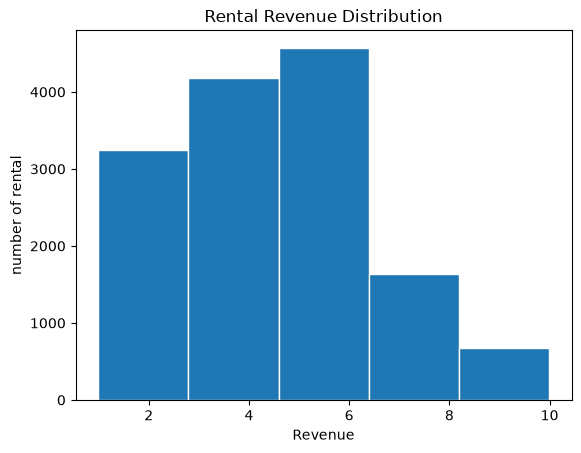

In [1113]:

plt.hist(df['payment_amount'], bins=5, edgecolor= "white")
plt.title('Rental Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('number of rental')
plt.show()

In [1064]:
#number of retal per customer

rentals_per_customer = (
    df.groupby('customer_id')['rental_id']
      .count()
)

rentals_per_customer.head()

customer_id
1    30
2    25
3    23
4    22
5    34
Name: rental_id, dtype: int64

In [1065]:
rentals_per_customer.describe()

count    599.000000
mean      23.883139
std        4.986574
min        7.000000
25%       20.000000
50%       24.000000
75%       27.000000
max       43.000000
Name: rental_id, dtype: float64

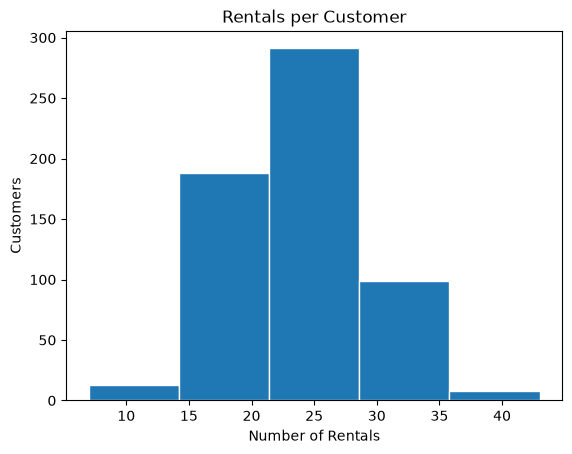

In [1116]:
plt.hist(rentals_per_customer, bins=5, edgecolor='white')
plt.title('Rentals per Customer')
plt.xlabel('Number of Rentals')
plt.ylabel('Customers')
plt.show()

In [1067]:
#Rental duration

df['rental_duration'].describe()

count    14306.000000
mean         4.504544
std          2.617637
min          0.000000
25%          2.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: rental_duration, dtype: float64

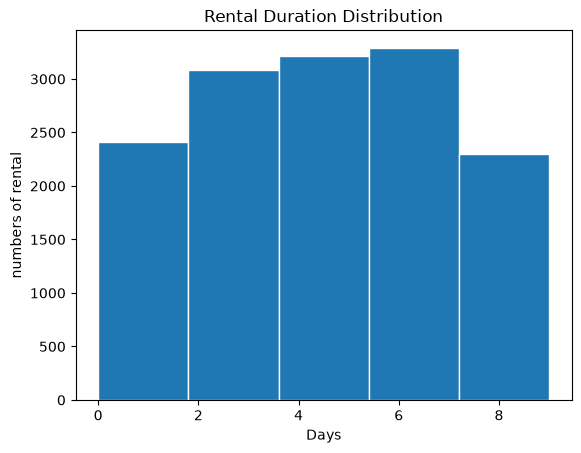

In [1068]:
plt.hist(df['rental_duration'], bins=5, edgecolor='white')
plt.title('Rental Duration Distribution')
plt.xlabel('Days')
plt.ylabel('numbers of rental')
plt.show()

In [1069]:
df

,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
0,1520,2005-06-15 23:57:20,341,Peter Menard,Ede,Netherlands,749,Rules Human,Horror,153,1,1,Mike Hillyer,7.99,2007-02-15 22:25:46.996577,8.0
1,1778,2005-06-16 18:54:48,341,Peter Menard,Ede,Netherlands,552,Majestic Floats,Documentary,130,1,2,Jon Stephens,1.99,2007-02-16 17:23:14.996577,5.0
2,1849,2005-06-17 00:13:19,341,Peter Menard,Ede,Netherlands,551,Maiden Home,New,138,1,2,Jon Stephens,7.99,2007-02-16 22:41:45.996577,6.0
3,2829,2005-06-19 21:11:30,341,Peter Menard,Ede,Netherlands,445,Hyde Doctor,Classics,100,1,1,Mike Hillyer,2.99,2007-02-19 19:39:56.996577,4.0
4,3130,2005-06-20 19:03:22,341,Peter Menard,Ede,Netherlands,563,Massacre Usual,Games,165,1,2,Jon Stephens,7.99,2007-02-20 17:31:48.996577,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14409,5340,2005-07-09 17:11:35,267,Margie Wade,Lengshuijiang,China,141,Chicago North,Games,185,1,2,Jon Stephens,6.99,2007-04-09 15:40:01.996577,8.0
14410,6070,2005-07-11 04:47:42,267,Margie Wade,Lengshuijiang,China,366,Goldfinger Sensibility,Drama,93,1,2,Jon Stephens,0.99,2007-04-11 03:16:08.996577,1.0
14411,6706,2005-07-12 12:59:16,267,Margie Wade,Lengshuijiang,China,993,Wrong Behavior,Children,178,1,1,Mike Hillyer,3.99,2007-04-12 11:27:42.996577,6.0
14412,8190,2005-07-28 22:47:06,267,Margie Wade,Lengshuijiang,China,496,Kick Savannah,Travel,179,1,1,Mike Hillyer,4.99,2007-04-28 21:15:32.996577,6.0


In [1070]:
df["customer_name"].unique()

<ArrowStringArray>
[     'Peter Menard',    'Harold Martino',      'Douglas Graf',
 'Henry Billingsley',        'Carl Artis',   'Arthur Simpkins',
    'Ryan Salisbury', 'Roger Quintanilla',     'Joe Gilliland',
       'Juan Fraley',
 ...
   'Walter Perryman',    'Patrick Newsom',     'Tony Carranza',
          'Don Bone',     'Bernard Colby',    'Micheal Forman',
    'Pedro Chestnut',  'Katherine Rivera',       'Peggy Myers',
      'Vanessa Sims']
Length: 599, dtype: str

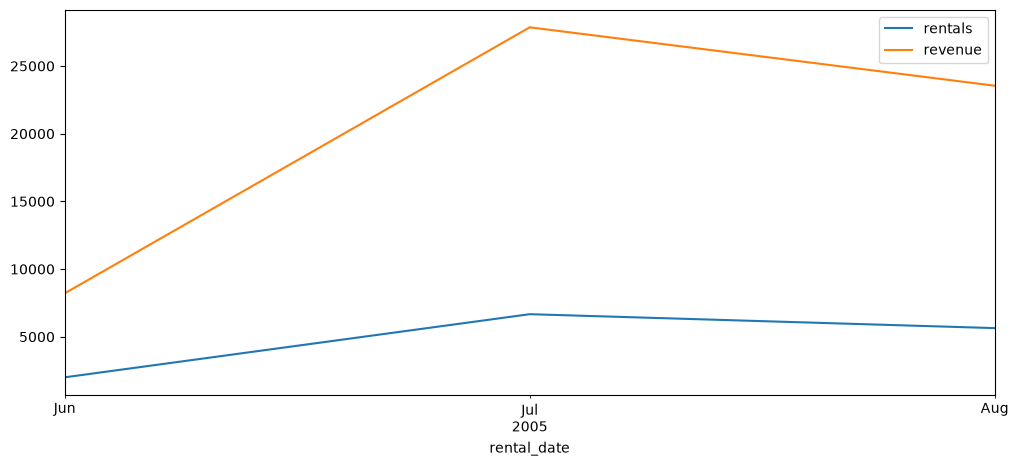

In [1071]:
#Rentals and Revenue Over Time
monthly = (
    df.groupby(
        df['rental_date'].dt.to_period('M')
    )
    .agg(
        rentals=('rental_id','count'),
        revenue=('payment_amount','sum')
    )
)

monthly.plot(figsize=(12,5))
plt.show()

In [1072]:
#Best and Worst Months

monthly.sort_values(
    'revenue',
    ascending=False
)

,rentals,revenue
rental_date,,
2005-07,6666,27858.34
2005-08,5638,23544.62
2005-06,2002,8206.98


In [1073]:
#Category Growth

category_monthly = (
    df.groupby([
        df['rental_date'].dt.to_period('M'),
        'category'
    ])
    .agg(
        revenue=('payment_amount','sum')
    )
    .reset_index()
)

category_monthly

,rental_date,category,revenue
0,2005-06,Action,628.52
1,2005-06,Animation,558.54
2,2005-06,Children,426.84
3,2005-06,Classics,459.81
4,2005-06,Comedy,542.84
5,2005-06,Documentary,497.67
6,2005-06,Drama,583.70
7,2005-06,Family,474.70
8,2005-06,Foreign,534.68
9,2005-06,Games,540.76


In [1074]:
#Repeat Renters

rentals_per_customer = (
    df.groupby('customer_id')['rental_id']
      .count()
)
rentals_per_customer

customer_id
1      30
2      25
3      23
4      22
5      34
       ..
595    28
596    21
597    22
598    22
599    18
Name: rental_id, Length: 599, dtype: int64

In [1075]:
repeat_pct = (
    (rentals_per_customer > 1).mean()
    * 100
)

print(repeat_pct)

100.0


In [1076]:
#Average Spending per Customer

customer_spend = (
    df.groupby('customer_id')['payment_amount']
      .sum()
)

customer_spend

customer_id
1      114.70
2      112.75
3      119.77
4       81.78
5      133.66
        ...  
595     99.72
596     72.79
597     82.78
598     83.78
599     78.82
Name: payment_amount, Length: 599, dtype: float64

In [1077]:
customer_spend.mean()

np.float64(99.51575959933223)

In [1078]:
#Average Gap Between Rentals

# df = df.sort_values(
#     ['customer_id','rental_date']
# )

# df['gap'] = (
#     df.groupby('customer_id')['rental_date']
#       .diff()
#       .dt.days
# )

# df['gap'].mean()



df = df.sort_values(['customer_id', 'rental_date'])

average_gap = (
    df.groupby('customer_id')['rental_date']
      .diff()
      .dt.days
      .mean()
)

print(f"Average gap between rentals: {average_gap:.2f} days")

Average gap between rentals: 2.40 days


In [1079]:
#Churn Risk

last_date = df['rental_date'].max()

customer_last = (
    df.groupby('customer_id')['rental_date']
      .max()
)

days_since = (
    last_date - customer_last
).dt.days

churn = days_since > 60

print(churn.sum())

0


In [1080]:
#Film & Category Insights

#Which films generate the most revenue per rental?

film_perf = (
    df.groupby('film_title')
      .agg(
          revenue=('payment_amount','sum'),
          rentals=('rental_id','count')
      )
)

film_perf['revenue_per_rental'] = (
    film_perf['revenue'] /
    film_perf['rentals']
)

film_perf.sort_values(
    'revenue_per_rental',
    ascending=False
).head(1)

,revenue,rentals,revenue_per_rental
film_title,,,
Backlash Undefeated,129.85,15,8.656667


In [1081]:
#Which categories have the highest average rental price?

df.groupby('category')['payment_amount'] \
  .mean() \
  .sort_values(ascending=False).head()

category
Comedy    4.653866
New       4.538810
Sports    4.490000
Games     4.401833
Horror    4.398971
Name: payment_amount, dtype: float64

In [1082]:
#Are longer movies rented more or less frequently?

film_stats = (
    df.groupby('film_title')
      .agg(
          length=('length','first'),
          rentals=('rental_id','count')
      )
)

film_stats[['length','rentals']].corr()

,length,rentals
length,1.000000,-0.037297
rentals,-0.037297,1.000000


In [1083]:
#Which films have high demand but low inventory?

df

,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
992,1185,2005-06-15 00:54:12,1,Mary Smith,Sasebo,Japan,611,Musketeers Wait,Classics,73,1,2,Jon Stephens,5.99,2007-02-14 23:22:38.996577,8.0
993,1422,2005-06-15 18:02:53,1,Mary Smith,Sasebo,Japan,228,Detective Vision,Classics,143,1,2,Jon Stephens,0.99,2007-02-15 16:31:19.996577,3.0
994,1476,2005-06-15 21:08:46,1,Mary Smith,Sasebo,Japan,308,Ferris Mother,Comedy,142,1,1,Mike Hillyer,9.99,2007-02-15 19:37:12.996577,9.0
995,1725,2005-06-16 15:18:57,1,Mary Smith,Sasebo,Japan,159,Closer Bang,Comedy,58,1,1,Mike Hillyer,4.99,2007-02-16 13:47:23.996577,1.0
996,2308,2005-06-18 08:41:48,1,Mary Smith,Sasebo,Japan,44,Attacks Hate,Sci-Fi,113,1,2,Jon Stephens,4.99,2007-02-18 07:10:14.996577,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,14599,2005-08-21 17:43:42,599,Austin Cintron,Tieli,China,1000,Zorro Ark,Comedy,50,2,1,Mike Hillyer,4.99,2007-03-21 16:12:08.996577,1.0
5116,14719,2005-08-21 21:41:57,599,Austin Cintron,Tieli,China,891,Timberland Sky,Classics,69,2,1,Mike Hillyer,1.99,2007-03-21 20:10:23.996577,3.0
5117,15590,2005-08-23 06:09:44,599,Austin Cintron,Tieli,China,881,Temple Attraction,Horror,71,2,2,Jon Stephens,8.99,2007-03-23 04:38:10.996577,9.0
5118,15719,2005-08-23 11:08:46,599,Austin Cintron,Tieli,China,869,Suspects Quills,Action,47,2,1,Mike Hillyer,2.99,2007-03-23 09:37:12.996577,1.0


In [1084]:
inventory

,store_id,film_id,category_id,film_title,category,inventory_count,total_rentals,total_revenue,last_rental_date,average_rental_duration_days
0,2.0,450,3,Idols Snatchers,Children,4,20,52.85,2005-08-23 20:27:34,4.82
1,1.0,535,11,Love Suicides,Horror,4,20,22.85,2005-08-23 18:23:11,5.20
2,2.0,875,15,Talented Homicide,Sports,4,19,22.85,2005-08-17 19:59:06,4.79
3,2.0,228,4,Detective Vision,Classics,4,19,37.84,2006-02-14 15:16:03,5.07
4,2.0,396,7,Hanging Deep,Drama,4,19,92.85,2005-08-20 23:42:31,4.73
...,...,...,...,...,...,...,...,...,...,...
1558,NaN,318,1,Firehouse Vietnam,Action,0,0,0.00,NaN,NaN
1559,NaN,497,6,Kill Brotherhood,Documentary,0,0,0.00,NaN,NaN
1560,NaN,325,2,Floats Garden,Animation,0,0,0.00,NaN,NaN
1561,NaN,87,16,Boondock Ballroom,Travel,0,0,0.00,NaN,NaN


In [1085]:
#Which films have high demand but low inventory?

# High demand + low inventory films

high_demand = inventory['total_rentals'].quantile(0.75)
low_inventory = inventory['inventory_count'].quantile(0.25)

high_demand_low_inventory = (
    inventory[
        (inventory['total_rentals'] >= high_demand) &
        (inventory['inventory_count'] <= low_inventory)
    ]
    .sort_values('total_rentals', ascending=False)
)

high_demand_low_inventory[
    ['film_title', 'inventory_count', 'total_rentals']
]

,film_title,inventory_count,total_rentals
1014,Jungle Closer,2,13


In [1086]:
#Most Profitable Store

df.groupby('store_id')['payment_amount'] \
  .sum() \
  .sort_values(ascending=False)

store_id
1    32651.00
2    26958.94
Name: payment_amount, dtype: float64

In [1087]:
#Most Efficient Staff

df.groupby('staff_name') \
  .agg(
      revenue=('payment_amount','sum'),
      rentals=('rental_id','count')
  ) \
  .sort_values(
      'revenue',
      ascending=False
  )

,revenue,rentals
staff_name,,
Jon Stephens,29881.90,7110
Mike Hillyer,29728.04,7196


In [1088]:
#Which countries and cities are the most profitable?

#most profitable country

df.groupby('country')['payment_amount'] \
  .sum() \
  .sort_values(ascending=False).head()

country
India            5834.15
China            5107.26
United States    3577.46
Japan            3043.66
Mexico           2948.90
Name: payment_amount, dtype: float64

In [1089]:
#Most Profitable Cities

df.groupby('city')['payment_amount'] \
  .sum() \
  .sort_values(ascending=False).head()

city
Cape Coral             197.59
Apeldoorn              191.62
Molodetno              189.60
Saint-Denis            189.57
Santa Brbara dOeste    178.63
Name: payment_amount, dtype: float64

In [1090]:
#Business Recommendations & Strategic Insights

#Top 3 Categories to Invest In

category_performance = (
    df.groupby('category')
      .agg(
          rentals=('rental_id', 'count'),
          revenue=('payment_amount', 'sum')
      )
      .sort_values('revenue', ascending=False)
)

category_performance.head(3)

,rentals,revenue
category,,
Sports,1056,4741.44
Sci-Fi,988,4283.12
Animation,1038,4112.62


In [1091]:
#Underperforming Categories

category_performance.sort_values('revenue').head()

,rentals,revenue
category,,
Music,734,2991.66
Travel,752,3163.48
Children,851,3248.49
Classics,849,3306.51
Horror,758,3334.42


In [1092]:
#Pricing Strategy

pricing_analysis = (
    df.groupby('category')
      .agg(
          rentals=('rental_id','count'),
          revenue=('payment_amount','sum')
      )
)

pricing_analysis['avg_revenue_per_rental'] = (
    pricing_analysis['revenue']
    / pricing_analysis['rentals']
)

pricing_analysis.sort_values(
    'avg_revenue_per_rental',
    ascending=False
)

,rentals,revenue,avg_revenue_per_rental
category,,,
Comedy,833,3876.67,4.653866
New,840,3812.60,4.538810
Sports,1056,4741.44,4.490000
Games,862,3794.38,4.401833
Horror,758,3334.42,4.398971
Sci-Fi,988,4283.12,4.335142
Drama,938,3998.62,4.262921
Travel,752,3163.48,4.206755
Foreign,937,3853.63,4.112732


In [1093]:
#                      Business Recommendations & Strategic Insights

#         1 Which 3 film categories should the company invest more in? Why?

category_performance = (
    df.groupby('category')
      .agg(
          rentals=('rental_id', 'count'),
          revenue=('payment_amount', 'sum')
      )
      .sort_values('revenue', ascending=False)
)

category_performance.head(3)

,rentals,revenue
category,,
Sports,1056,4741.44
Sci-Fi,988,4283.12
Animation,1038,4112.62


In [1094]:
#    Sports generates the highest revenue and rental volume.
#    Sci-Fi consistently attracts customers and produces strong revenue.
#    Animation has very high rental demand, indicating strong customer interest.

In [1095]:
#         2 Which underperforming films or categories should be discontinued or promoted 

category_performance.sort_values('revenue').head()

,rentals,revenue
category,,
Music,734,2991.66
Travel,752,3163.48
Children,851,3248.49
Classics,849,3306.51
Horror,758,3334.42


In [1096]:
#     Reduce inventory levels for these films.
#     Bundle them with popular films.
#     Run promotional discounts before removing them entirely.

In [1097]:
#                  3 What pricing strategy would you recommend based on rental and revenue patterns?

#     Premium pricing for Sports and Sci-Fi titles.
#     Standard pricing for average-performing categories.
#     Discount pricing for Music, Travel, and low-demand films.
#     Offer bundle deals such as:
#         Rent 3 films, get 1 free.
#         Weekend category packs.

In [1098]:
#      Customer Retention Strategy
   #What actions should the company take to retain high-value customers?
#     VIP membership tier
#     Early access to new releases
#     Personalized recommendations
#     Bonus rental credits
#     Exclusive discounts

In [1099]:
          #  How should the company re-engage inactive or churn-risk customers?

#   Send email reminders after long inactivity.
#   Offer limited-time discounts.
#   Provide personalized film recommendations based on previous rentals.
#   Introduce "We miss you" promotions.

In [1100]:
      #  What type of loyalty program would you design based on customer behavior?

#  Points-Based Loyalty Program

In [1101]:
inventory.columns

Index(['store_id', 'film_id', 'category_id', 'film_title', 'category',
       'inventory_count', 'total_rentals', 'total_revenue', 'last_rental_date',
       'average_rental_duration_days'],
      dtype='str')

In [1102]:
    #   Which films should be restocked immediately due to high demand and low inventory

high_demand = inventory['total_rentals'].quantile(0.75)
low_inventory = inventory['inventory_count'].quantile(0.25)

high_demand_low_inventory = (
    inventory[
        (inventory['total_rentals'] >= high_demand) &
        (inventory['inventory_count'] <= low_inventory)
    ]
    .sort_values('total_rentals', ascending=False).head()
)

high_demand_low_inventory[
    ['film_title', 'inventory_count', 'total_rentals',]
]


,film_title,inventory_count,total_rentals
1014,Jungle Closer,2,13


In [1103]:
# Count rentals per film
film_demand = (
    df.groupby('film_title')
      .agg(
          rentals=('rental_id', 'count'),
          revenue=('payment_amount', 'sum')
      )
      .sort_values('rentals', ascending=False)
)

# Top 10 films that may need restocking
restock_films = film_demand.head(10)

print(restock_films)

                     rentals  revenue
film_title                           
Scalawag Duck             29   157.71
Rush Goodfellas           28    81.72
Apache Divine             28   160.72
Rocketeer Mother          28    97.72
Rugrats Shakespeare       28    67.72
Bucket Brotherhood        28   150.72
Grit Clockwork            28    97.72
Juggler Hardly            28    85.72
Dogma Family              28   168.72
Muscle Bright             27    86.73


In [1104]:
#Which films should be removed from inventory due to low performance?

low_rentals = inventory['total_rentals'].quantile(0.25)
high_inventory = inventory['inventory_count'].quantile(0.75)

films_to_remove = (
    inventory[
        (inventory['total_rentals'] <= low_rentals) &
        (inventory['inventory_count'] >= high_inventory)
    ]
    .sort_values('total_rentals')
    [['film_title', 'category', 'inventory_count',
      'total_rentals', 'total_revenue']]
)

films_to_remove

,film_title,category,inventory_count,total_rentals,total_revenue
524,Vertigo Northwest,Comedy,4,8,37.92


In [1105]:
df

,rental_id,rental_date,customer_id,customer_name,city,country,film_id,film_title,category,length,store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
992,1185,2005-06-15 00:54:12,1,Mary Smith,Sasebo,Japan,611,Musketeers Wait,Classics,73,1,2,Jon Stephens,5.99,2007-02-14 23:22:38.996577,8.0
993,1422,2005-06-15 18:02:53,1,Mary Smith,Sasebo,Japan,228,Detective Vision,Classics,143,1,2,Jon Stephens,0.99,2007-02-15 16:31:19.996577,3.0
994,1476,2005-06-15 21:08:46,1,Mary Smith,Sasebo,Japan,308,Ferris Mother,Comedy,142,1,1,Mike Hillyer,9.99,2007-02-15 19:37:12.996577,9.0
995,1725,2005-06-16 15:18:57,1,Mary Smith,Sasebo,Japan,159,Closer Bang,Comedy,58,1,1,Mike Hillyer,4.99,2007-02-16 13:47:23.996577,1.0
996,2308,2005-06-18 08:41:48,1,Mary Smith,Sasebo,Japan,44,Attacks Hate,Sci-Fi,113,1,2,Jon Stephens,4.99,2007-02-18 07:10:14.996577,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,14599,2005-08-21 17:43:42,599,Austin Cintron,Tieli,China,1000,Zorro Ark,Comedy,50,2,1,Mike Hillyer,4.99,2007-03-21 16:12:08.996577,1.0
5116,14719,2005-08-21 21:41:57,599,Austin Cintron,Tieli,China,891,Timberland Sky,Classics,69,2,1,Mike Hillyer,1.99,2007-03-21 20:10:23.996577,3.0
5117,15590,2005-08-23 06:09:44,599,Austin Cintron,Tieli,China,881,Temple Attraction,Horror,71,2,2,Jon Stephens,8.99,2007-03-23 04:38:10.996577,9.0
5118,15719,2005-08-23 11:08:46,599,Austin Cintron,Tieli,China,869,Suspects Quills,Action,47,2,1,Mike Hillyer,2.99,2007-03-23 09:37:12.996577,1.0


In [1106]:
#How should inventory differ by store or region

store_performance = (
    df.groupby('store_id')
      .agg(revenue=('payment_amount', 'sum'))
      .reset_index()
      .sort_values('revenue', ascending=False)
)

store_performance

,store_id,revenue
0,1,32651.00
1,2,26958.94


In [1107]:
#    Store 1 generates significantly more revenue.

#  Recommendation:

#     Allocate more inventory to Store 1.
#     Investigate why Store 1 outperforms Store 2.
#     Replicate successful practices across locations.



In [1108]:
df.info()

<class 'pandas.DataFrame'>
Index: 14306 entries, 992 to 5119
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   rental_id        14306 non-null  int64         
 1   rental_date      14306 non-null  datetime64[us]
 2   customer_id      14306 non-null  int64         
 3   customer_name    14306 non-null  str           
 4   city             14306 non-null  str           
 5   country          14306 non-null  str           
 6   film_id          14306 non-null  int64         
 7   film_title       14306 non-null  str           
 8   category         14306 non-null  str           
 9   length           14306 non-null  int64         
 10  store_id         14306 non-null  int64         
 11  staff_id         14306 non-null  int64         
 12  staff_name       14306 non-null  str           
 13  payment_amount   14306 non-null  float64       
 14  payment_date     14306 non-null  datetime64[us]
 15  

In [1109]:
df.to_csv("film_dataset_2.csv")

In [1110]:
df.isna().sum()

rental_id          0
rental_date        0
customer_id        0
customer_name      0
city               0
country            0
film_id            0
film_title         0
category           0
length             0
store_id           0
staff_id           0
staff_name         0
payment_amount     0
payment_date       0
rental_duration    0
dtype: int64